**Project: Kathmandu Weather AQI 2019–2020**

1. Import Libraries

In [2]:
# Import pandas for data loading and data manipulation (tables, CSV files)
import pandas as pd
# Import numpy for numerical operations (arrays, math functions)
import numpy as np
# Import matplotlib for basic plotting and visualizations
import matplotlib.pyplot as plt
# Import seaborn for advanced and nicer-looking statistical plots
import seaborn as sns
# Import train_test_split to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Import LinearRegression model for prediction
from sklearn.linear_model import LinearRegression
# Import evaluation metrics to measure model performance
from sklearn.metrics import mean_squared_error, r2_score

# Sets a clean “whitegrid” style for all Seaborn plots. Improves readability by adding light gridlines to charts.
sns.set(style='whitegrid')


2. Load Dataset

In [3]:
# Read the CSV file and load it into a pandas DataFrame
aqi_df = pd.read_csv('Kathmandu-Weather-AQI-Dataset-2020.csv')

# Display the first 5 rows of the dataset
display(aqi_df.head())

# Show detailed information about the dataset
aqi_df.info()


,Date and Time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),rain (mm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h)
0,2019-01-01 00:00,4.0,71,-0.7,0.0,1019.6,866.1,0,0.23,6.7,164,11.2
1,2019-01-01 01:00,5.4,65,-0.7,0.0,1020.5,867.5,0,0.32,3.8,163,14.8
2,2019-01-01 02:00,6.4,64,0.0,0.0,1021.4,868.8,0,0.35,4.5,166,14.0
3,2019-01-01 03:00,10.0,58,2.2,0.0,1022.2,871.2,0,0.51,5.7,162,16.6
4,2019-01-01 04:00,12.9,40,-0.4,0.0,1022.4,872.8,0,0.90,2.6,106,15.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date and Time                  8760 non-null   object 
 1   temperature_2m (°C)            8760 non-null   float64
 2   relative_humidity_2m (%)       8760 non-null   int64  
 3   dew_point_2m (°C)              8760 non-null   float64
 4   rain (mm)                      8760 non-null   float64
 5   pressure_msl (hPa)             8760 non-null   float64
 6   surface_pressure (hPa)         8760 non-null   float64
 7   cloud_cover (%)                8760 non-null   int64  
 8   vapour_pressure_deficit (kPa)  8760 non-null   float64
 9   wind_speed_10m (km/h)          8760 non-null   float64
 10  wind_direction_10m (°)         8760 non-null   int64  
 11  wind_gusts_10m (km/h)          8760 non-null   float64
dtypes: float64(8), int64(3), object(1)
memory usage:

The dataset contains 8760 rows because:
1 year × 365 days × 24 hours = 8760 hours
So this is hourly weather data for Kathmandu in 2020 with 12 features, no missing values, and mostly numerical data, making it suitable for machine learning analysis.

3. Data Cleaning & Preprocessing

In [4]:
# Drop all rows that contain missing (NaN) values
# inplace=True means the changes are applied directly to the original DataFrame
aqi_df.dropna(inplace=True)
# Check the shape of the DataFrame after dropping missing values
print("Shape of the DataFrame after dropping missing values:", aqi_df.shape)

Shape of the DataFrame after dropping missing values: (8760, 12)


Convert Date to datetime type and add year, month, day and hour columns.

In [5]:
# Convert the 'Date and Time' column from string/object type to datetime type
# This lets us perform time-based operations like filtering by month, day, or hour
aqi_df['Date and Time'] = pd.to_datetime(aqi_df['Date and Time'])

# Extract the year from 'Date and Time' and create a new column 'Year'
# Example: 2020-01-01 05:00 → 2020
aqi_df['Year'] = aqi_df['Date and Time'].dt.year

# Extract the month from 'Date and Time' and create a new column 'Month'
# Example: 2020-01-01 05:00 → 1 (January)
aqi_df['Month'] = aqi_df['Date and Time'].dt.month

# Extract the day of the month from 'Date and Time' and create a new column 'Day'
# Example: 2020-01-01 05:00 → 1
aqi_df['Day'] = aqi_df['Date and Time'].dt.day

# Extract the hour from 'Date and Time' and create a new column 'Hour'
# Example: 2020-01-01 05:00 → 5
aqi_df['Hour'] = aqi_df['Date and Time'].dt.hour



4. Exploratory Data Analysis(EDA)

In [6]:
# 4.1 Summary Statistics
# Step 1: List all numeric columns that we want to analyze
# These are weather and wind-related measurements
aqi_df.rename(columns={
    'temperature_2m (°C)': 'Temperature',        # Air temperature at 2 meters above ground
    'relative_humidity_2m (%)':'Humidity',   # Humidity percentage
    'dew_point_2m (°C)': 'Dew Point',          # Dew point temperature
    'rain (mm)': 'Rainfall',                  # Rainfall in millimeters
    'pressure_msl (hPa)': 'Pressure MSL',         # Mean sea level pressure
    'surface_pressure (hPa)': 'Surface Pressure',     # Surface air pressure
    'cloud_cover (%)': 'Cloud Cover',            # Cloud coverage percentage
    'vapour_pressure_deficit (kPa)': 'Vapour Pressure Deficit', # Dryness of air
    'wind_speed_10m (km/h)': 'Wind Speed',      # Wind speed at 10 meters
    'wind_direction_10m (°)': 'Wind Direction',     # Wind direction in degrees
    'wind_gusts_10m (km/h)': 'Wind Gusts'       # Maximum wind gusts at 10 meters
}, inplace=True)

# Step 2: Use describe() to generate summary statistics for these numeric columns
numeric_cols = ['Temperature', 'Humidity', 'Dew Point', 'Rainfall', 'Pressure MSL', 'Surface Pressure', 'Cloud Cover', 'Vapour Pressure Deficit', 'Wind Speed', 'Wind Direction', 'Wind Gusts']
print(aqi_df[numeric_cols].describe())

       Temperature     Humidity    Dew Point     Rainfall  Pressure MSL  \
count  8760.000000  8760.000000  8760.000000  8760.000000   8760.000000   
mean     17.198893    78.897831    13.161758     0.389110   1011.577032   
std       5.658621    16.003623     6.289404     1.467363      5.711571   
min       0.600000    20.000000    -8.600000     0.000000    997.200000   
25%      13.200000    69.000000     7.500000     0.000000   1007.000000   
50%      18.300000    82.000000    14.100000     0.000000   1012.400000   
75%      21.400000    93.000000    19.200000     0.100000   1016.200000   
max      29.000000   100.000000    23.900000    30.300000   1024.700000   

       Surface Pressure  Cloud Cover  Vapour Pressure Deficit   Wind Speed  \
count       8760.000000  8760.000000              8760.000000  8760.000000   
mean         865.478539    39.192237                 0.446994     3.809189   
std            3.547411    34.737655                 0.406634     2.118011   
min         

In [7]:
print(aqi_df.columns)


Index(['Date and Time', 'Temperature', 'Humidity', 'Dew Point', 'Rainfall',
       'Pressure MSL', 'Surface Pressure', 'Cloud Cover',
       'Vapour Pressure Deficit', 'Wind Speed', 'Wind Direction', 'Wind Gusts',
       'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


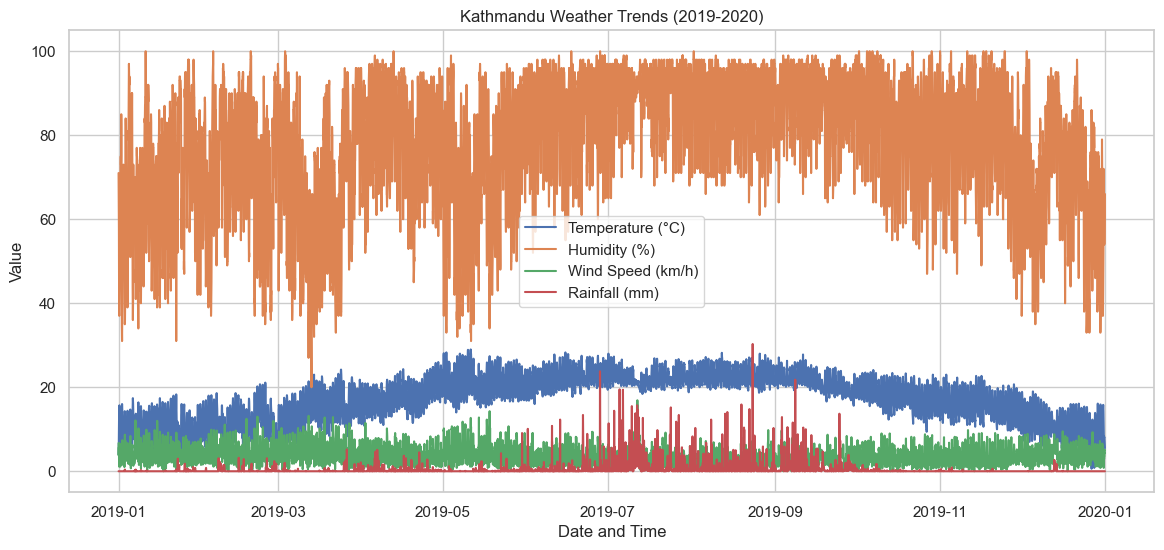

In [8]:
# 4.2 Weather Trends Over Time
# Step 1: Ensure 'Date and Time' column is in datetime format
aqi_df['Date and Time'] = pd.to_datetime(aqi_df['Date and Time'])

# Step 2: Set the figure size for the plot (width=14 inches, height=6 inches)
plt.figure(figsize=(14,6))

# Step 3: Plot multiple weather variables over time using Seaborn's lineplot
# x-axis: Date and Time, y-axis: the weather variable
# label: name for the legend
sns.lineplot(x='Date and Time', y='Temperature', data=aqi_df, label='Temperature (°C)')   # Air temperature trend
sns.lineplot(x='Date and Time', y='Humidity', data=aqi_df, label='Humidity (%)')            # Relative humidity trend
sns.lineplot(x='Date and Time', y='Wind Speed', data=aqi_df, label='Wind Speed (km/h)')    # Wind speed trend
sns.lineplot(x='Date and Time', y='Rainfall', data=aqi_df, label='Rainfall (mm)')          # Rainfall trend

# Step 4: Add plot title and axis labels
plt.title('Kathmandu Weather Trends (2019-2020)')  # Main title of the chart
plt.xlabel('Date and Time')                         # Label for x-axis
plt.ylabel('Value')                                 # Label for y-axis

# Step 5: Display the legend so each line is identified
plt.legend()  

# Step 6: Render the plot
plt.show()


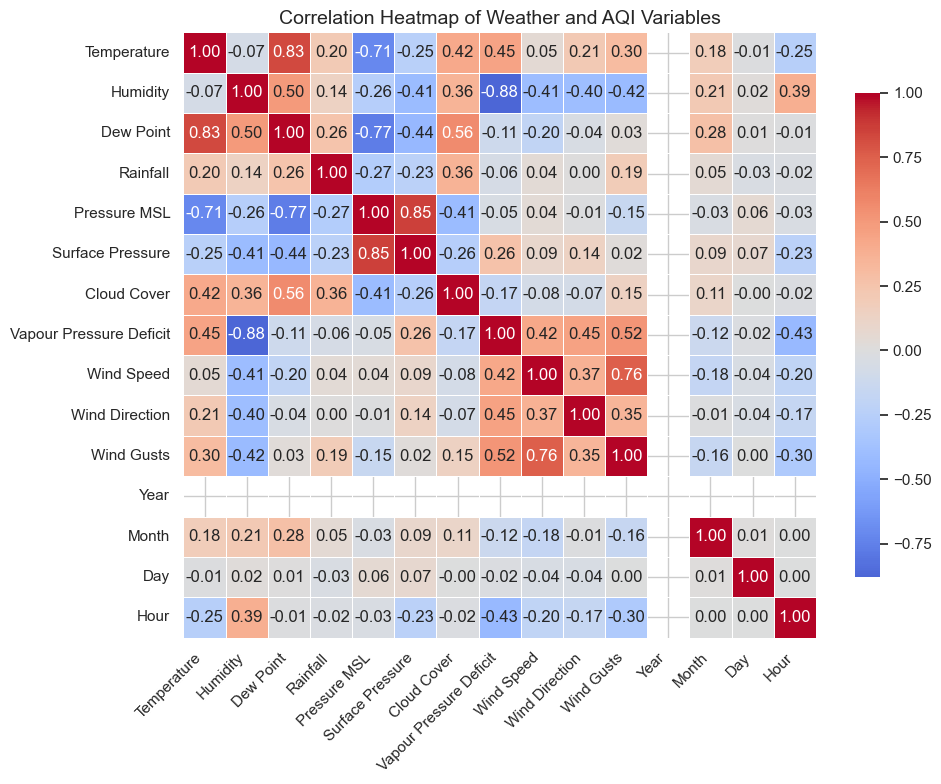

In [12]:
# 4.3 Improved Correlation Heatmap

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select only numeric columns
# Correlation is meaningful only for numerical data
corr_matrix = aqi_df.select_dtypes(include=np.number).corr()

# Step 2: Create a mask to hide the upper triangle
# This removes duplicate mirrored values and improves readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 3: Create the figure with a larger size
plt.figure(figsize=(10,8))

# Step 4: Plot the heatmap
sns.heatmap(
    corr_matrix,                 # correlation matrix to plot
    annot=True,               # show correlation values
    fmt=".2f",                # round values to 2 decimals
    cmap="coolwarm",          # red = positive, blue = negative
    center=0,                 # center color scale at zero
    linewidths=0.5,           # lines between cells
    cbar_kws={"shrink": 0.8}  # resize color bar
)

# Step 5: Improve axis labels readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Step 6: Add a descriptive title
plt.title('Correlation Heatmap of Weather and AQI Variables', fontsize=14)

# Step 7: Adjust layout
plt.tight_layout()

# Step 8: Display the heatmap
plt.show()


C:\Users\97798\AppData\Local\Temp\ipykernel_16676\2498517687.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\97798\AppData\Local\Temp\ipykernel_16676\2498517687.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\97798\AppData\Local\Temp\ipykernel_16676\2498517687.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\97798\AppData\Local\Temp\ipykernel_16676\2498517687.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

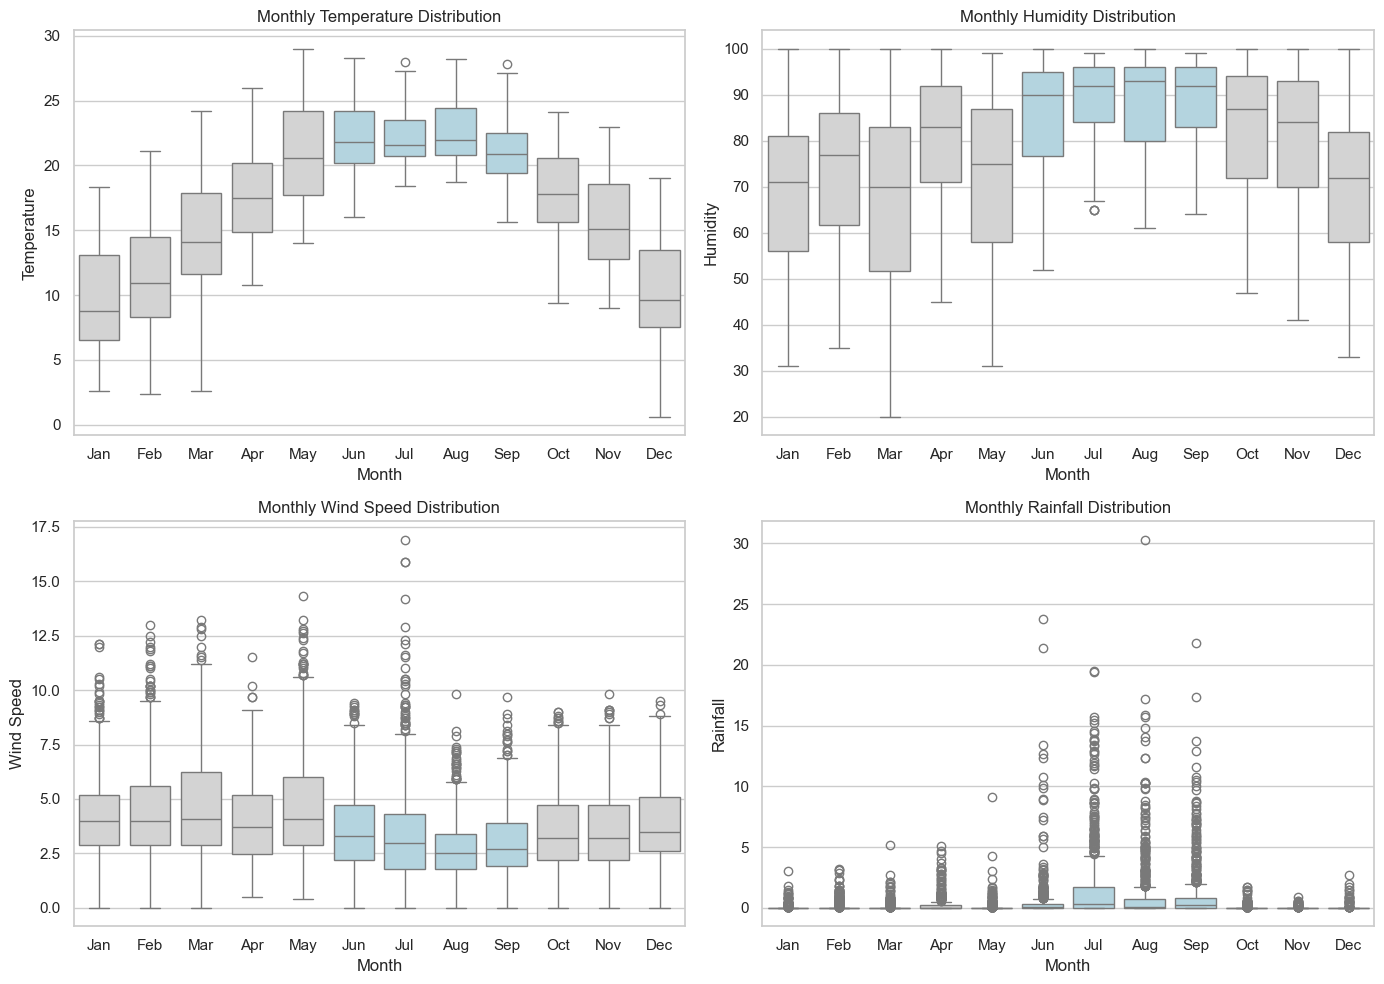

In [10]:
import matplotlib.pyplot as plt   # Library for plotting graphs
import seaborn as sns             # Library for statistical data visualization
import calendar                   # To convert month numbers to month names
import pandas as pd               # For data manipulation

# Step 1: Ensure 'Date and Time' is datetime and extract month abbreviation
# This creates a new column 'Month' with values like 'Jan', 'Feb', etc.
aqi_df['Month'] = pd.to_datetime(aqi_df['Date and Time']).dt.month.apply(lambda x: calendar.month_abbr[x])

# Step 2: Define weather variables to visualize
weather_vars = ['Temperature', 'Humidity', 'Wind Speed', 'Rainfall']

# Step 3: Define the chronological order of months for the x-axis
months_order = list(calendar.month_abbr[1:])  # ['Jan', 'Feb', ..., 'Dec']

# Step 4: Define monsoon months to highlight in the plots
monsoon = {'Jun', 'Jul', 'Aug', 'Sep'}  # Monsoon months

# Step 5: Create a 2x2 grid of subplots for 4 weather variables
fig, axes = plt.subplots(2, 2, figsize=(14,10))  # 2 rows, 2 columns, figure size 14x10 inches

# Step 6: Loop through each axis and variable to plot boxplots
for ax, var in zip(axes.flatten(), weather_vars):
    sns.boxplot(
        x='Month',                  # Month on x-axis
        y=var,                      # Weather variable on y-axis
        data=aqi_df,                # Data source
        order=months_order,         # Keep months in chronological order
        palette=[                   # Assign colors: light blue for monsoon months, grey for others
            'lightblue' if m in monsoon else 'lightgrey' 
            for m in months_order
        ],
        ax=ax                        # Plot in the current subplot axis
    )
    ax.set_title(f'Monthly {var} Distribution')  # Set subplot title

# Step 7: Adjust spacing between subplots to prevent overlap
plt.tight_layout()

# Step 8: Display the figure
plt.show()


5. Predictive Modeling

In [15]:
print(aqi_df.columns)

Index(['Date and Time', 'Temperature', 'Humidity', 'Dew Point', 'Rainfall',
       'Pressure MSL', 'Surface Pressure', 'Cloud Cover',
       'Vapour Pressure Deficit', 'Wind Speed', 'Wind Direction', 'Wind Gusts',
       'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


In [11]:
# 5. Predictive Modeling: Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features: Humidity, Wind Speed, Rainfall
X = aqi_df[['Humidity','Wind Speed','Rainfall']]
y = aqi_df['Temperature']  # Target variable

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


Mean Squared Error: 32.48
R-squared: 0.06


6. Visualization of Prediction

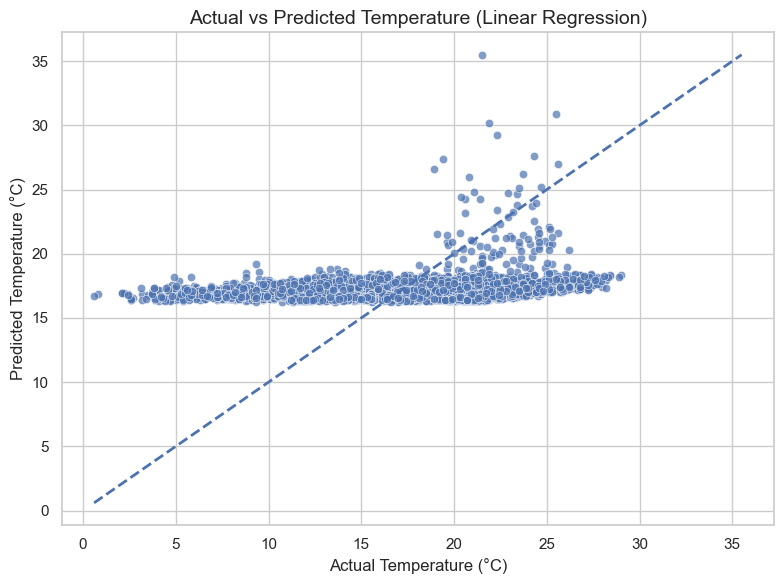

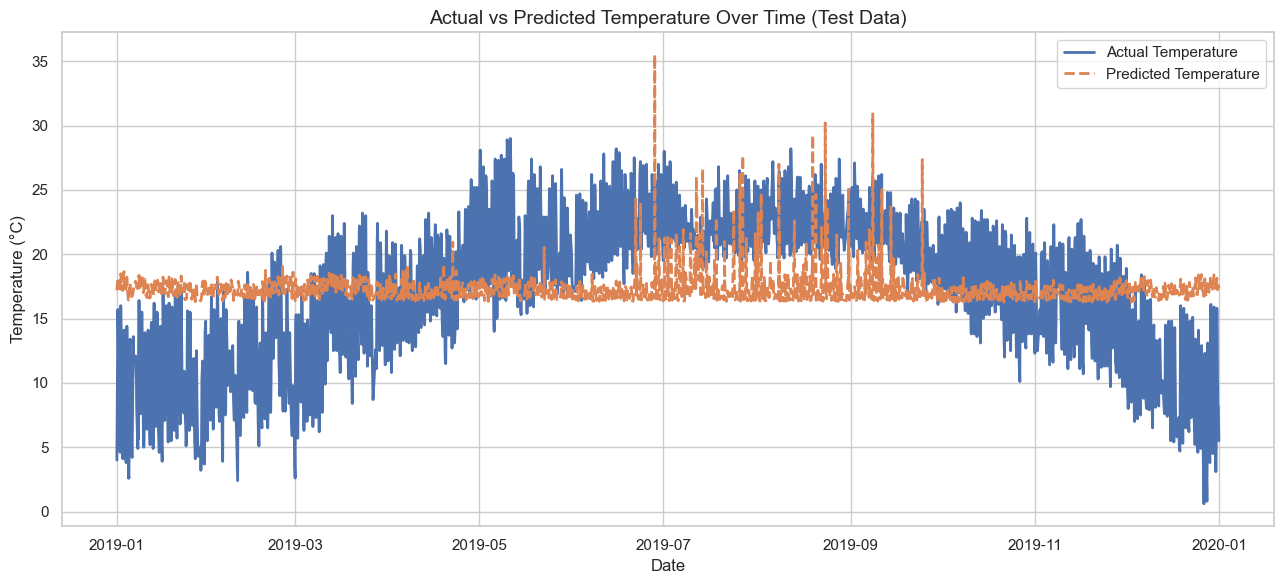

In [19]:
# 6. Visualization of Predictions

# Import required libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set a clean background style for plots
sns.set_theme(style="whitegrid")


# ==============================
# SCATTER PLOT: ACTUAL vs PREDICTED
# ==============================

# Create a new figure with fixed size
plt.figure(figsize=(8,6))

# Scatter plot:
# x-axis → actual temperature values (from test data)
# y-axis → predicted temperature values (from model)
# alpha → controls transparency of points
sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.7
)

# Create a "perfect prediction" reference line (y = x)
# If all predictions were perfect, all points would lie on this line
min_val = min(y_test.min(), y_pred.min())   # lowest value
max_val = max(y_test.max(), y_pred.max())   # highest value

# Plot the reference diagonal line
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2
)

# Label the axes
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)

# Add plot title
plt.title('Actual vs Predicted Temperature (Linear Regression)', fontsize=14)

# Adjust layout to avoid overlapping elements
plt.tight_layout()

# Display the scatter plot
plt.show()


# ==============================
# TIME SERIES PLOT (TEST DATA ONLY)
# ==============================

# Create a DataFrame to combine:
# - Date
# - Actual temperature
# - Predicted temperature
# This helps in plotting time-based comparison
pred_df = pd.DataFrame({
    'Date': aqi_df.loc[X_test.index, 'Date and Time'],  # corresponding dates
    'Actual': y_test,                                   # true values
    'Predicted': y_pred                                 # model predictions
}).sort_values('Date')  # sort by date for proper time sequence

# Create a new figure for time series plot
plt.figure(figsize=(13,6))

# Plot actual temperature over time
plt.plot(
    pred_df['Date'],
    pred_df['Actual'],
    label='Actual Temperature',
    linewidth=2
)

# Plot predicted temperature over time
plt.plot(
    pred_df['Date'],
    pred_df['Predicted'],
    label='Predicted Temperature',
    linestyle='--',
    linewidth=2
)

# Label axes
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# Add title
plt.title('Actual vs Predicted Temperature Over Time (Test Data)', fontsize=14)

# Show legend to distinguish lines
plt.legend()

# Adjust layout
plt.tight_layout()

# Display the time series plot
plt.show()


Histogram

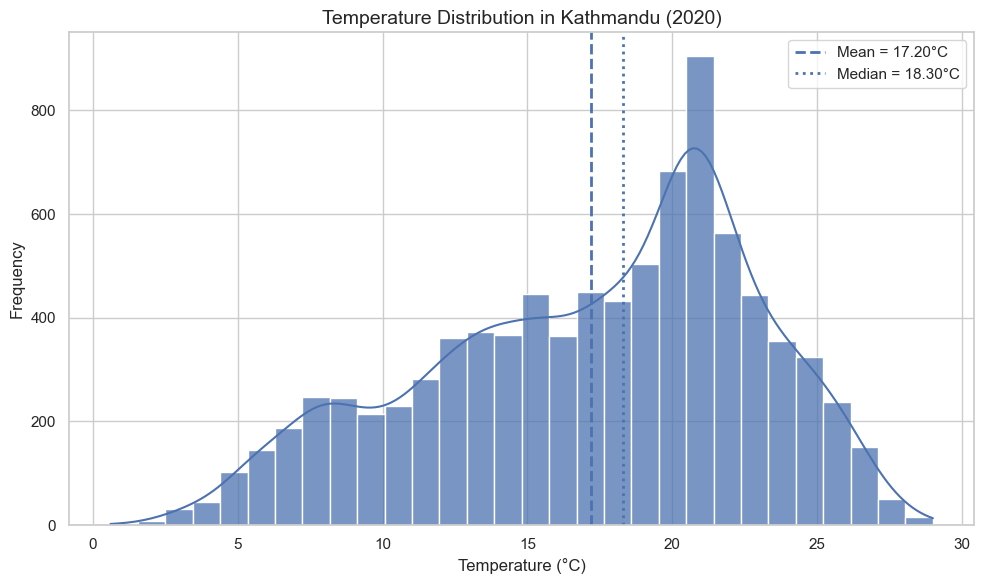

In [ ]:
# 7.1 Histogram of Temperature

# Create a figure with a fixed size for better visibility
plt.figure(figsize=(10,6))

# Plot a histogram of temperature values
# bins=30 → divides data into 30 temperature ranges
# kde=True → adds a smooth density curve to show distribution shape
# alpha=0.75 → controls transparency of bars
sns.histplot(
    aqi_df['Temperature'],   # Temperature data
    bins=30,
    kde=True,
    alpha=0.75
)

# Calculate the mean (average) temperature
mean_temp = aqi_df['Temperature'].mean()

# Calculate the median (middle value) temperature
median_temp = aqi_df['Temperature'].median()

# Draw a vertical dashed line to represent the mean temperature
plt.axvline(
    mean_temp,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_temp:.2f}°C'
)

# Draw a vertical dotted line to represent the median temperature
plt.axvline(
    median_temp,
    linestyle=':',
    linewidth=2,
    label=f'Median = {median_temp:.2f}°C'
)

# Add a title to the histogram
plt.title('Temperature Distribution in Kathmandu (2020)', fontsize=14)

# Label the x-axis
plt.xlabel('Temperature (°C)', fontsize=12)

# Label the y-axis
plt.ylabel('Frequency', fontsize=12)

# Display legend showing mean and median lines
plt.legend()

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the histogram
plt.show()


Bar chart

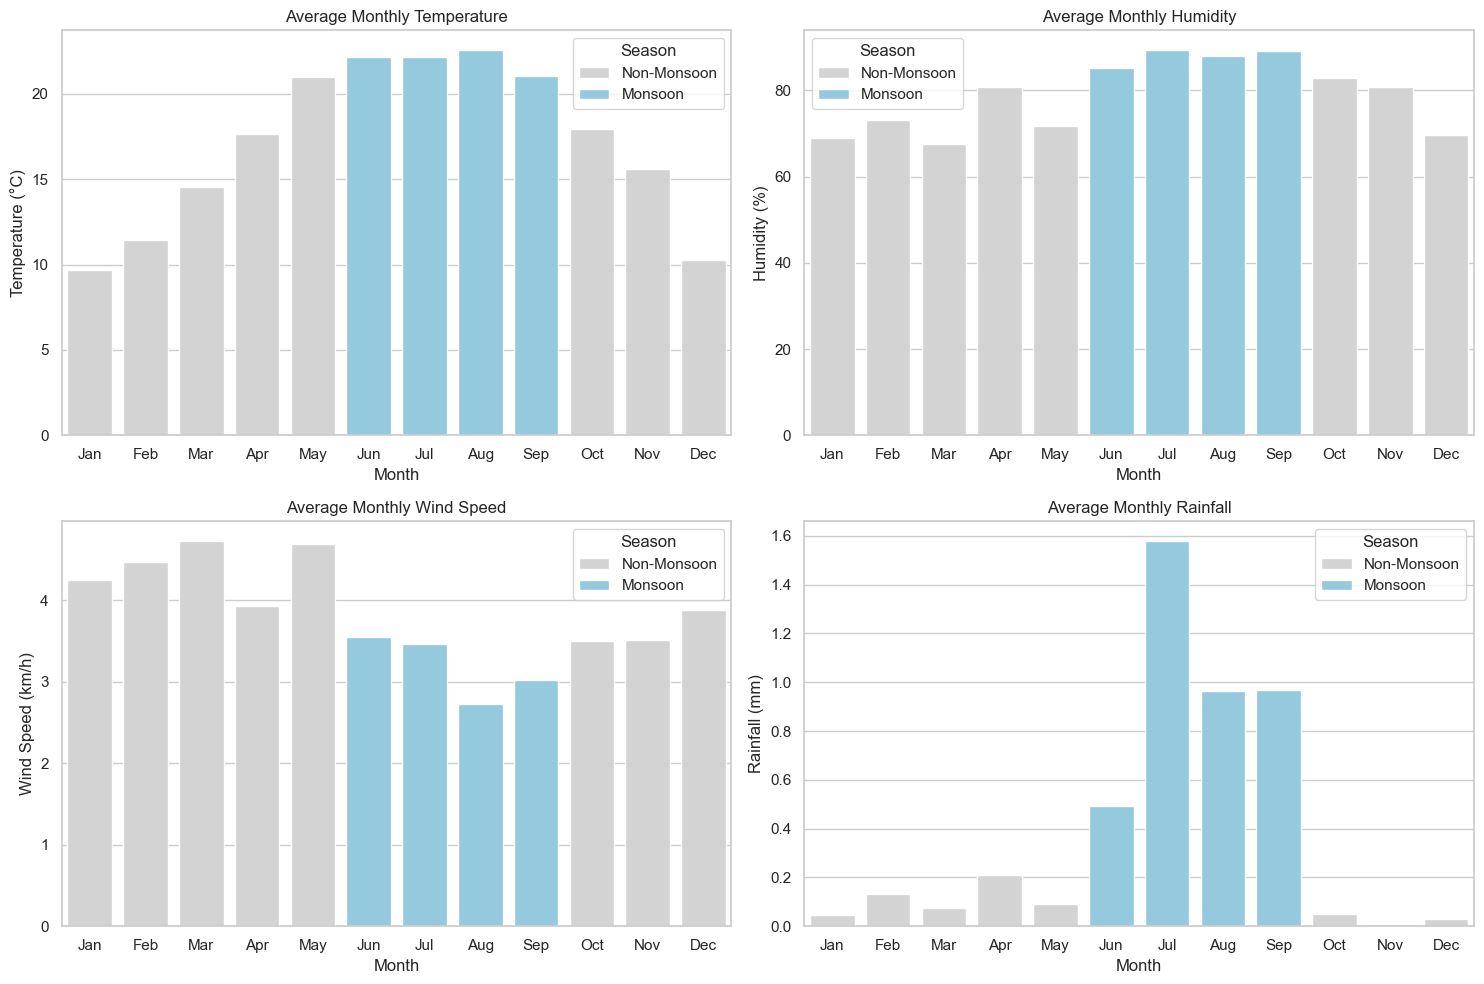

In [16]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Seaborn style
sns.set(style="whitegrid")

# Ensure datetime format
aqi_df['Date and Time'] = pd.to_datetime(aqi_df['Date and Time'])

# Create Month column (Jan, Feb, ...)
aqi_df['Month'] = aqi_df['Date and Time'].dt.month.apply(
    lambda x: calendar.month_abbr[x]
)

# Define month order and monsoon months
months_order = list(calendar.month_abbr[1:])  # Jan–Dec
monsoon_months = ['Jun', 'Jul', 'Aug', 'Sep']

# Calculate monthly averages
monthly_avg = (
    aqi_df
    .groupby('Month')[['Temperature', 'Humidity', 'Wind Speed', 'Rainfall']]
    .mean()
    .reindex(months_order)
    .reset_index()
)

# Add column to identify monsoon months
monthly_avg['Season'] = monthly_avg['Month'].apply(
    lambda x: 'Monsoon' if x in monsoon_months else 'Non-Monsoon'
)

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(15,10))

variables = ['Temperature', 'Humidity', 'Wind Speed', 'Rainfall']
y_labels = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (km/h)', 'Rainfall (mm)']

# Plot each variable
for ax, var, ylab in zip(axes.flatten(), variables, y_labels):
    sns.barplot(
        data=monthly_avg,
        x='Month',
        y=var,
        hue='Season',
        order=months_order,
        palette={'Monsoon': 'skyblue', 'Non-Monsoon': 'lightgray'},
        ax=ax
    )
    
    ax.set_title(f'Average Monthly {var}', fontsize=12)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylab)
    ax.legend(title='Season')

# Adjust layout
plt.tight_layout()
plt.show()


8. Ethical Consideration

In [17]:
print("""
Ethical Considerations for AQI Dataset:
1. Data Privacy: No personal data involved.
2. Representativeness: Data from Kathmandu only, not rural areas.
3. Accuracy: Predictions are approximate; cannot be used for alarms without validation.
4. Data Quality: Ensure Kaggle dataset source is reliable.
""")



Ethical Considerations for AQI Dataset:
1. Data Privacy: No personal data involved.
2. Representativeness: Data from Kathmandu only, not rural areas.
3. Accuracy: Predictions are approximate; cannot be used for alarms without validation.
4. Data Quality: Ensure Kaggle dataset source is reliable.

